# Base

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from tqdm import tqdm
import h5py
import hdf5plugin
import os
from dataclasses import astuple, asdict

In [2]:
from deep_bf.config_registery import  ConfigRegisteryCenter, BeamformerConfig, ResamplerConfig, ApodConfig, DataSizeConfig, CompoundingConfig
from deep_bf.config_registery.path_center import PathCenter
from deep_bf.data_handler import DataLoader
from deep_bf.constants.bf import BeamformerType, CompooundingType

with PathCenter(location="local") as pc:
    dataset_paths = pc.dataset_paths
    dl_path = pc.dl
    DL = DataLoader(dl_path)
    
with ConfigRegisteryCenter() as cc:
    dasC = cc.get_beamformer(id=0)
    mvC = cc.get_beamformer(id=1)
    fdmasC = cc.get_beamformer(id=2)
    cfC = cc.get_beamformer(id=3)
    imapC = cc.get_beamformer(id=4)
    sr1C = cc.get_beamformer(id=5)

    gsC = cc.get_resampler(id=2)

    nC = cc.get_apod(id=0)

    dsC = cc.get_data_size(id=0)

    cpC = cc.get_compounding(id=1)
    aaspC = cc.get_compounding(id=2)
    edtC = cc.get_compounding(id=4)

In [3]:
print(fdmasC)

BeamformerConfig(id=2, type='F-DMAS', params={'BW': 0.5, 'transition_low_ratio': 0.6, 'transition_high_ratio': 0.4, 'ripple': 0.001, 'batch_size': 128, 'eps': 1e-10, 'min_band_bins': 4})


# Setup Configuration

In [4]:
#bfs = [dasC]
#bfs = [dasC, mvC]
bfs = [dasC, mvC, fdmasC, cfC, imapC]

resamplers = [gsC]
apods = [nC]
data_sizes = [dsC]

compoundings = [cpC]

In [5]:
from deep_bf.constants.bf import PWDataType

df = DL.get_df()
df = df.query("RF == 1 and nc == 128")
df = df[df["name"].str[:3] != "JHU"]

names = df["name"]
#names = ["MYO001", "MYO002", "TSH003", "carotid_cross_expe_dataset_rf"]
print(len(names))

angle_batch_size = 5
mode = PWDataType.RF

550


# Precalentamiento

In [21]:
from deep_bf.wrapper.bench.classic_bench import ClassicBench
from deep_bf.wrapper.bench.classic_bench2 import ClassicBench2
from deep_bf.wrapper.reconstruction.reconstruction_catalog import ReconstructionCatalog

pw = DL.get_defined_pwdata("TSH003", mode)

for _ in range(10):
    catalog: ReconstructionCatalog = ClassicBench2(
    pw,
    data_sizes=data_sizes,
    bfs=[dasC],
    resamplers=resamplers,
    apods=[nC],
    compoundings=compoundings,
    angles=[-1],
    angle_batch_size=angle_batch_size,
)()

# Testing Visual

In [22]:
from deep_bf.constants.bf import PWDataType

picmus_names = [
    "contrast_speckle_expe_dataset_rf",
    "contrast_speckle_simu_dataset_rf",
    "resolution_distorsion_expe_dataset_rf",
    "resolution_distorsion_simu_dataset_rf",
    "carotid_cross_expe_dataset_rf",
    "carotid_long_expe_dataset_rf"
]

name = picmus_names[1]
#name = picmus_names[0]
#name = picmus_names[5]
#name = "TSH342"

pw = DL.get_defined_pwdata(name, PWDataType.RF)

In [23]:
# CLASSIC BENCH 2

from deep_bf.constants.bf import PWDataType
from deep_bf.wrapper.bench.classic_bench2 import ClassicBench2
from deep_bf.wrapper.reconstruction.reconstruction_catalog import ReconstructionCatalog

mode = PWDataType.RF
angles = [-1]
angle_batch_size = 5
catalog: ReconstructionCatalog = ClassicBench2(
    pw,
    data_sizes=data_sizes,
    bfs=bfs,
    resamplers=resamplers,
    apods=apods,
    compoundings=compoundings,
    angles=angles,
    angle_batch_size=angle_batch_size,
)()

reconstructions = catalog.all()
print(reconstructions)

[name: contrast_speckle_simu_dataset_rf
mode: RF
shape: (2048, 256)
dtype: float32
limits_mm: z=[5.000, 50.000], x=[-19.200, 19.200]
pipeline: bf=DAS | resampler=GridSample | apod=None | compounding=CoherentPlane-WaveCompoundingWithMean
data_size: nz=2048, nx=256, ns=2300
  times: total=6.0174s, batches=16, name: contrast_speckle_simu_dataset_rf
mode: RF
shape: (2048, 256)
dtype: float32
limits_mm: z=[5.000, 50.000], x=[-19.200, 19.200]
pipeline: bf=MV | resampler=GridSample | apod=None | compounding=CoherentPlane-WaveCompoundingWithMean
data_size: nz=2048, nx=256, ns=2300
  times: total=6.5031s, batches=16, name: contrast_speckle_simu_dataset_rf
mode: RF
shape: (2048, 256)
dtype: float32
limits_mm: z=[5.000, 50.000], x=[-19.200, 19.200]
pipeline: bf=F-DMAS | resampler=GridSample | apod=None | compounding=CoherentPlane-WaveCompoundingWithMean
data_size: nz=2048, nx=256, ns=2300
  times: total=6.6532s, batches=16, name: contrast_speckle_simu_dataset_rf
mode: RF
shape: (2048, 256)
dtype:

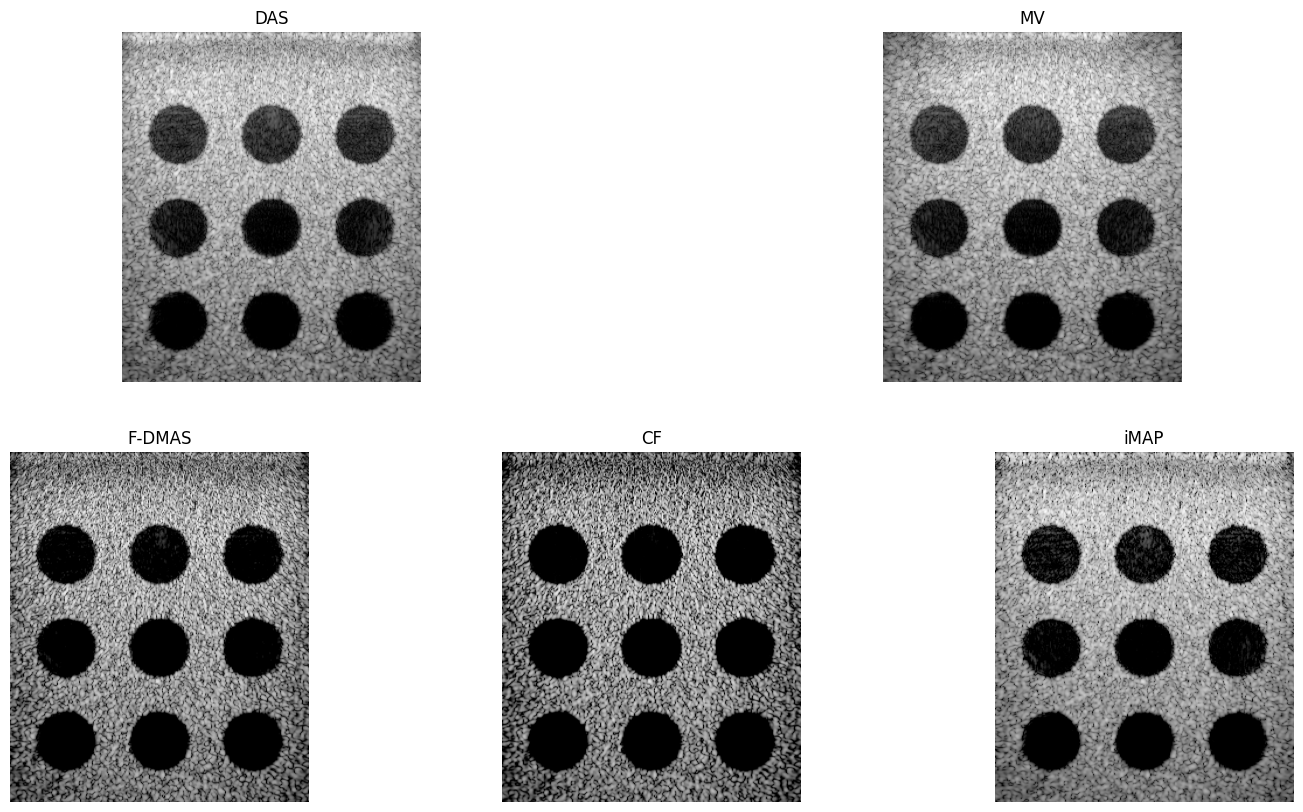

In [24]:
import matplotlib.pyplot as plt
from deep_bf.wrapper.plot.grid_planner import get_axes_flex
from deep_bf.wrapper.plot.ax_plot import simple_bmode, get_bf_title

vmin = -60
vmax = 0

fig, axes_flatten = get_axes_flex([2, 3], figsize=(18, 10))
for ax, r in zip(axes_flatten, reconstructions):
    ax = simple_bmode(ax, r, get_bf_title, vmin, vmax)

# GT Creator

In [25]:
from deep_bf.webdataset.utils.hdf5.create import save_ground_truth_hdf5

from tqdm import tqdm

angle_batch_size = 5
mode = PWDataType.RF

for name in tqdm(names, desc="PWs", unit="pw"):
    pw = DL.get_defined_pwdata(name, mode)

    catalog: ReconstructionCatalog = ClassicBench2(
        pw,
        data_sizes=data_sizes,
        bfs=bfs,
        resamplers=resamplers,
        apods=apods,
        compoundings=compoundings,
        angles=[-1],
        angle_batch_size=angle_batch_size,
    )()

    reconstructions = catalog.all()

    for r in reconstructions:
        save_ground_truth_hdf5(r, "local")

PWs: 100%|██████████| 550/550 [21:04<00:00,  2.30s/pw]


# Comprobar

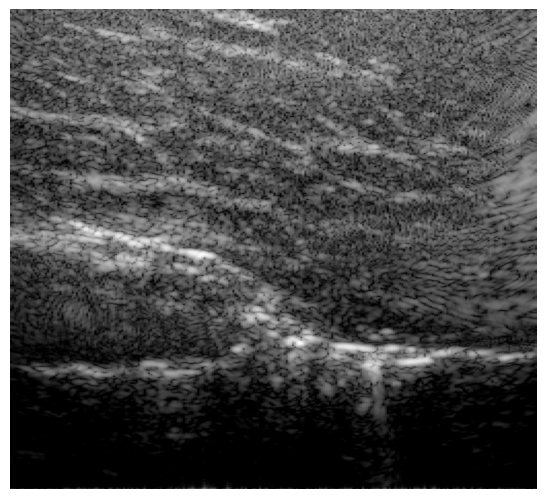

In [10]:
import matplotlib.pyplot as plt
from deep_bf.wrapper.plot.ax_plot import simple_bmode, get_bf_title
from deep_bf.wrapper.plot.simple_plot import show_simple_plot
from deep_bf.webdataset.utils.hdf5.load import get_ground_truth_hdf5
from deep_bf.beamformers.utils.b_mode import get_bmode

from deep_bf.constants.bf import PWDataType

picmus_names = [
    "contrast_speckle_expe_dataset_rf",
    "contrast_speckle_simu_dataset_rf",
    "resolution_distorsion_expe_dataset_rf",
    "resolution_distorsion_simu_dataset_rf",
    "carotid_cross_expe_dataset_rf",
    "carotid_long_expe_dataset_rf"
]

#name = picmus_names[1]
name = "TSH342"

pw = DL.get_defined_pwdata(name, PWDataType.RF)

data = get_ground_truth_hdf5(name, mode, mvC, gsC, nC, cpC, dsC, "local")

vmin = -60
vmax = 0
eps = 1e-10

bmode = get_bmode(data, mode, vmin, vmax)

show_simple_plot(bmode, pw, vmin=vmin, vmax=vmax)

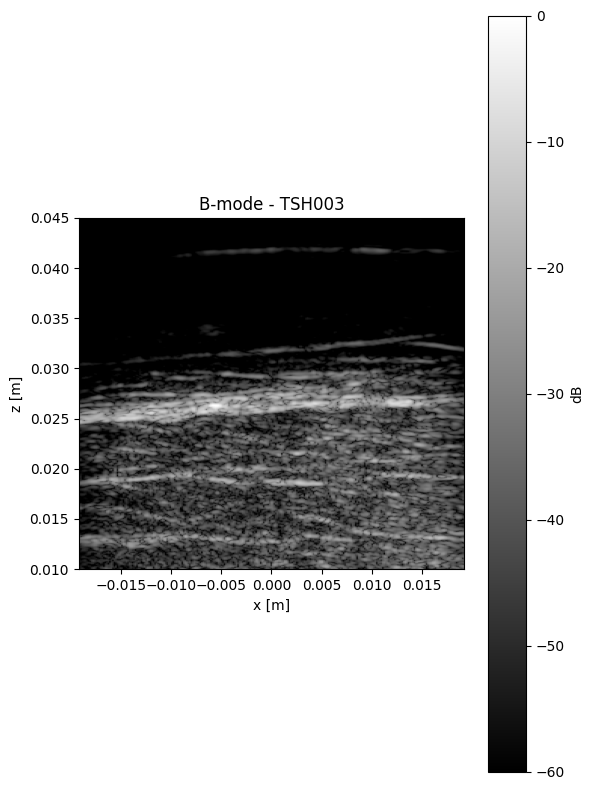

In [ ]:
import matplotlib.pyplot as plt
from deep_bf.webdataset.utils.ground_truth import get_ground_truth_hdf5
from deep_bf.beamformers.utils.b_mode import get_bmode

name = "TSH003"
pw = DL.get_defined_pwdata(name, mode)
zlims = pw.zlims
xlims = pw.xlims

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])

xd1 = DataSizeConfig(11, 2048, 256, -1)
xd2 = DataSizeConfig(11, 1024, 256, -1)

data = get_ground_truth_hdf5(name, mode, srC, gsC, draC, cpC, dsC, "local")

bmode = get_bmode(data, mode, -60, 0)

plt.figure(figsize=(6, 8))
plt.imshow(
    bmode,
    cmap="gray",
    vmin=-60,
    vmax=0,
    extent=extent,
    aspect="equal",
)
plt.title(f"B-mode - {name}")
plt.xlabel("x [m]")
plt.ylabel("z [m]")
plt.gca().invert_yaxis()  # opcional, si quieres z creciente hacia abajo
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [ ]:
from deep_bf.config_registery import ConfigRegisteryCenter
from deep_bf.models.bf.extractor import get_name2id, save_samples_idx_hdf5

with ConfigRegisteryCenter() as cc:
    wdbC = cc.get_webdataset_beamformer_packing(id=3)

query = wdbC.samples_organization_config.query
name2id = get_name2id(query)
print(name2id)

seen = set()
for key, value in name2id.items():
    if value not in seen:
        print(f"{key}: {value}")
        seen.add(value)

save_samples_idx_hdf5(2048, 256, query, "local")

/home/panda/miniconda3/envs/pytorch/lib/python3.14/site-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


{'TSH002': 0, 'TSH003': 0, 'TSH004': 0, 'TSH005': 0, 'TSH006': 0, 'TSH007': 0, 'TSH008': 0, 'TSH009': 0, 'TSH010': 0, 'TSH011': 0, 'TSH012': 0, 'TSH013': 0, 'TSH014': 0, 'TSH015': 0, 'TSH016': 0, 'TSH017': 0, 'TSH018': 0, 'TSH019': 0, 'TSH020': 0, 'TSH021': 0, 'TSH022': 0, 'TSH023': 0, 'TSH024': 0, 'TSH025': 0, 'TSH026': 0, 'TSH027': 0, 'TSH028': 0, 'TSH029': 0, 'TSH030': 0, 'TSH031': 0, 'TSH032': 0, 'TSH033': 0, 'TSH034': 0, 'TSH035': 0, 'TSH036': 0, 'TSH037': 0, 'TSH038': 0, 'TSH039': 0, 'TSH040': 0, 'TSH041': 0, 'TSH042': 0, 'TSH043': 0, 'TSH044': 0, 'TSH045': 0, 'TSH046': 0, 'TSH047': 0, 'TSH048': 0, 'TSH049': 0, 'TSH050': 0, 'TSH051': 0, 'TSH052': 0, 'TSH053': 0, 'TSH054': 0, 'TSH055': 0, 'TSH056': 0, 'TSH057': 0, 'TSH058': 0, 'TSH059': 0, 'TSH060': 0, 'TSH061': 0, 'TSH062': 0, 'TSH063': 0, 'TSH064': 0, 'TSH065': 0, 'TSH066': 0, 'TSH067': 0, 'TSH068': 0, 'TSH069': 0, 'TSH070': 0, 'TSH071': 0, 'TSH072': 0, 'TSH073': 0, 'TSH074': 0, 'TSH075': 0, 'TSH076': 0, 'TSH077': 0, 'TSH078': 0